In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    matthews_corrcoef,
)

RANDOM_STATE = 42
pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

fmt = lambda v: f"{v:.4f}"
print("ready")

ready


In [2]:
data = load_breast_cancer()

print("target_names:", list(data.target_names))
for value, name in enumerate(data.target_names):
    n = (data.target == value).sum()
    print(f"  target = {value} ->  {name:<10s} {n:>4d} cases ({n/len(data.target):.1%})")

target_names: [np.str_('malignant'), np.str_('benign')]
  target = 0 ->  malignant   212 cases (37.3%)
  target = 1 ->  benign      357 cases (62.7%)


In [3]:
X = data.data
y = (data.target == 0).astype(int)              # 1 = malignant, the class we care about
CLASSES = ["benign", "malignant"]

print(f"positives (malignant): {y.sum():>4d}  prevalence {y.mean():.1%}")
print(f"negatives (benign):    {(1 - y).sum():>4d}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
print(f"\ntrain {X_train.shape[0]} rows | test {X_test.shape[0]} rows")
print(f"stratify keeps the prevalence: train {y_train.mean():.3f} | test {y_test.mean():.3f}")

positives (malignant):  212  prevalence 37.3%
negatives (benign):     357

train 398 rows | test 171 rows
stratify keeps the prevalence: train 0.372 | test 0.374


In [4]:
ranges = pd.DataFrame({"min": X.min(axis=0), "max": X.max(axis=0)},
                      index=data.feature_names)
print("a few feature ranges -- four orders of magnitude apart:")
print(ranges.loc[["mean fractal dimension", "mean smoothness", "mean radius",
                  "mean perimeter", "worst area"]].to_string(float_format=lambda v: f"{v:10.4f}"))

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "SVM (RBF)": make_pipeline(
        StandardScaler(), SVC(probability=True, random_state=RANDOM_STATE)),
}
for name, m in models.items():
    m.fit(X_train, y_train)

# What scaling is actually worth on this data:
raw_svm = SVC(random_state=RANDOM_STATE).fit(X_train, y_train)
print(f"\nSVM without scaling: accuracy {accuracy_score(y_test, raw_svm.predict(X_test)):.4f}")
print(f"SVM with scaling:    accuracy {accuracy_score(y_test, models['SVM (RBF)'].predict(X_test)):.4f}")
print("Same algorithm. The gap is preprocessing, not the model.")

a few feature ranges -- four orders of magnitude apart:
                              min        max
mean fractal dimension     0.0500     0.0974
mean smoothness            0.0526     0.1634
mean radius                6.9810    28.1100
mean perimeter            43.7900   188.5000
worst area               185.2000  4254.0000

SVM without scaling: accuracy 0.9006
SVM with scaling:    accuracy 0.9591
Same algorithm. The gap is preprocessing, not the model.


In [5]:
model = models["Logistic Regression"]
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)        # rows = truth, columns = prediction
tn, fp, fn, tp = cm.ravel()

print("scikit-learn puts TRUTH on the rows and PREDICTION on the columns.")
print("Slide 28 warns about this: several textbooks print the transpose.\n")
print(pd.DataFrame(cm,
                   index=[f"actual {c}" for c in CLASSES],
                   columns=[f"predicted {c}" for c in CLASSES]))

print(f"\nTP = {tp:>3d}   malignant, correctly caught")
print(f"FN = {fn:>3d}   malignant, missed             <-- the dangerous error")
print(f"FP = {fp:>3d}   benign, false alarm")
print(f"TN = {tn:>3d}   benign, correctly cleared")

scikit-learn puts TRUTH on the rows and PREDICTION on the columns.
Slide 28 warns about this: several textbooks print the transpose.

                  predicted benign  predicted malignant
actual benign                  106                    1
actual malignant                 4                   60

TP =  60   malignant, correctly caught
FN =   4   malignant, missed             <-- the dangerous error
FP =   1   benign, false alarm
TN = 106   benign, correctly cleared


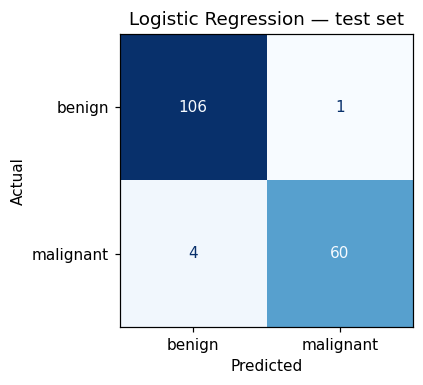

In [6]:
fig, ax = plt.subplots(figsize=(4.3, 3.6))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Logistic Regression — test set")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

In [7]:
print(f"accuracy from the matrix : {((tp + tn) / cm.sum()):.4f}")
print(f"accuracy from sklearn    : {accuracy_score(y_test, y_pred):.4f}")

accuracy from the matrix : 0.9708
accuracy from sklearn    : 0.9708


In [8]:
from sklearn.datasets import make_classification

X_imb, y_imb = make_classification(
    n_samples=20_000, n_features=20, n_informative=6, n_redundant=2,
    weights=[0.99, 0.01], flip_y=0.01, class_sep=0.9, random_state=RANDOM_STATE
)

X_imb_tr, X_imb_te, y_imb_tr, y_imb_te = train_test_split(
    X_imb, y_imb, test_size=0.30, random_state=RANDOM_STATE, stratify=y_imb
)

print(f"synthetic fraud data: {len(y_imb):,} rows, prevalence {y_imb.mean():.2%}")
print(f"  train {len(y_imb_tr):,} rows  ({y_imb_tr.sum()} frauds)")
print(f"  test  {len(y_imb_te):,} rows  ({y_imb_te.sum()} frauds)")

synthetic fraud data: 20,000 rows, prevalence 1.45%
  train 14,000 rows  (203 frauds)
  test  6,000 rows  (87 frauds)
